# Notebook 02: Exploratory Data Analysis (EDA) – Flugdaten

Dieses Notebook dient der explorativen Datenanalyse der Flugdaten mit dem Ziel, Muster, Trends und Ausreißer im Datensatz zu identifizieren. Im Fokus stehen Preisstrukturen, Buchungsmerkmale, Reisedauer und saisonale Unterschiede zwischen verschiedenen Flugangeboten.

## Ziel der Analyse
- Verständnis der Struktur und Qualität der Daten
- Identifikation auffälliger Muster und Verteilungen
- Analyse von Preis-, Airline- und Reisezeit-Variationen
- Bewertung von Zusammenhängen zwischen Buchungsparametern
- Vorbereitung für weiterführende Analysen und Modellierungen

## Datengrundlage
Der Datensatz enthält Informationen zu Flügen, darunter:
- Preise und Preisindizes
- Airline und Abflug-/Zielflughafen
- Reisezeit und One-Way vs. Round-Trip
- Sitzplatzanzahl, Gepäck und Abflugzeit
- monatliche und wöchentliche Zeitmuster

## Methodik
- Bereinigung und Vorverarbeitung der Daten
- Berechnung zusätzlicher Kennzahlen wie Preis pro Sitzplatz
- Visuelle Analyse mit Histogrammen, Boxplots und Balkendiagrammen
- Untersuchung von Verteilungen, Trends und Korrelationen
- Interpretation zentraler Muster im Zusammenhang mit dem Geschäftsbereich Luftverkehr

## Erwartete Erkenntnisse
- Preisunterschiede je nach Airline, Reisedauer und Buchungsart
- Saisonale oder wöchentliche Muster im Flugaufkommen
- Einflussfaktoren auf Flugpreise und Buchungsentscheidungen
- Zusammenhänge zwischen Preis, Dauer und Angebotsmerkmalen

## Abschluss
Die Ergebnisse dieser EDA bilden die Grundlage für nachgelagerte Analysen, z. B. für Segmentierung, Preisoptimierung oder Prognosen. Sie helfen dabei, die wichtigsten Treiber im Flugmarkt verständlich zu erfassen und gezielt zu interpretieren.

In [2]:
import pandas as pd

df_users = pd.read_csv("../data/raw/users.csv")
df_users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10
...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06


In [3]:
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5782 non-null   int64  
 1   birthdate         5782 non-null   str    
 2   gender            5782 non-null   str    
 3   married           5782 non-null   bool   
 4   has_children      5782 non-null   bool   
 5   home_country      5782 non-null   str    
 6   home_city         5782 non-null   str    
 7   home_airport      5782 non-null   str    
 8   home_airport_lat  5782 non-null   float64
 9   home_airport_lon  5782 non-null   float64
 10  sign_up_date      5782 non-null   str    
dtypes: bool(2), float64(2), int64(1), str(6)
memory usage: 418.0 KB


In [4]:
df_users.isna().sum()

user_id             0
birthdate           0
gender              0
married             0
has_children        0
home_country        0
home_city           0
home_airport        0
home_airport_lat    0
home_airport_lon    0
sign_up_date        0
dtype: int64

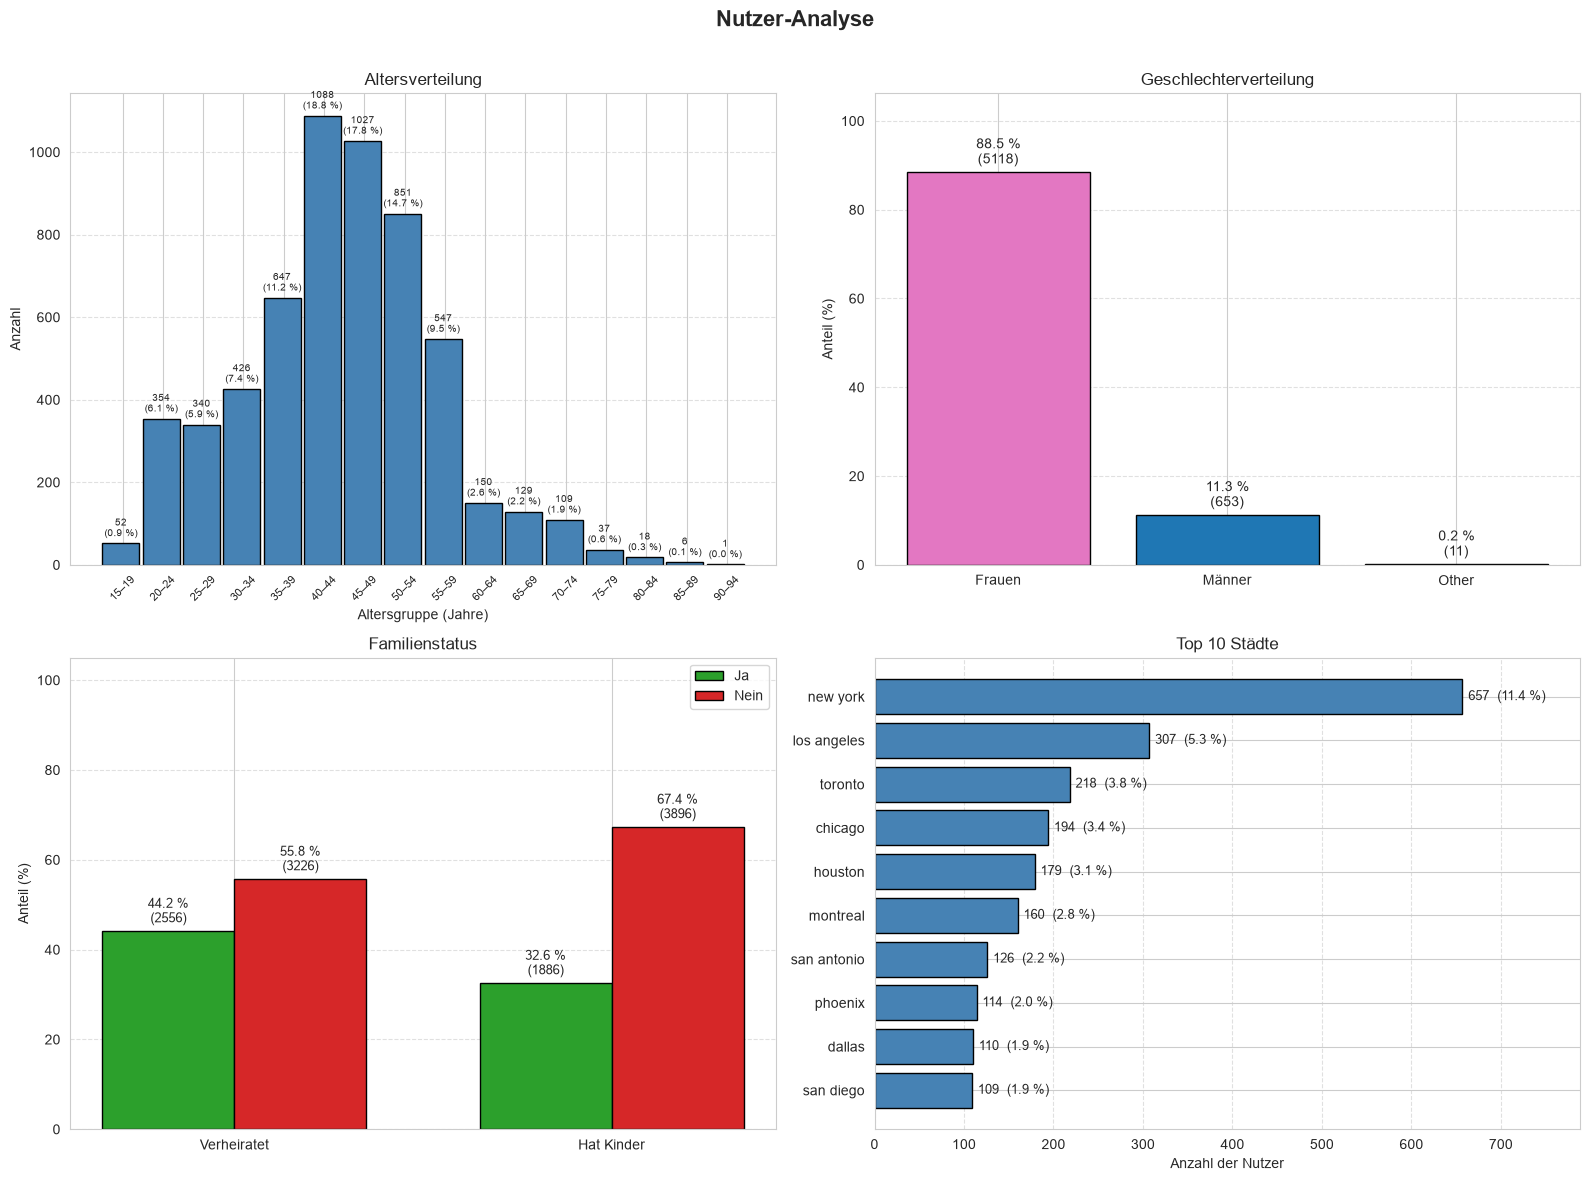

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------- Vorbereitung ----------
df_users["birthdate"] = pd.to_datetime(df_users["birthdate"], errors="coerce")
df_users["age"] = ((pd.Timestamp.today() - df_users["birthdate"]).dt.days // 365.25).astype("Int64")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Nutzer-Analyse", fontsize=16, fontweight="bold")

# ---------- 1) Altersverteilung (5-Jahres-Bins) ----------
ax = axes[0, 0]
ages = df_users["age"].dropna().astype(int)
min_age = ages.min() // 5 * 5
max_age = ages.max() // 5 * 5 + 5
bins = np.arange(min_age, max_age + 5, 5)
counts, edges = np.histogram(ages, bins=bins)
prozent = counts / counts.sum() * 100

bars = ax.bar(edges[:-1], counts, width=4.6, align="edge",
              edgecolor="black", color="steelblue")
for c, p, bar in zip(counts, prozent, bars):
    if c > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts) * 0.01,
                f"{c}\n({p:.1f} %)",
                ha="center", va="bottom", fontsize=7)

mitte = (edges[:-1] + edges[1:]) / 2
ax.set_xticks(mitte)
ax.set_xticklabels([f"{int(e)}–{int(e)+4}" for e in edges[:-1]],
                   rotation=45, fontsize=8)
ax.set_xlabel("Altersgruppe (Jahre)")
ax.set_ylabel("Anzahl")
ax.set_title("Altersverteilung")
ax.grid(axis="y", linestyle="--", alpha=0.6)

# ---------- 2) Geschlechterverteilung ----------
ax = axes[0, 1]
g_counts = df_users["gender"].value_counts().reindex(["F", "M", "O"]).fillna(0).astype(int)
g_proz = g_counts / g_counts.sum() * 100
g_labels = ["Frauen", "Männer", "Other"]
g_colors = ["#e377c2", "#1f77b4", "#7f7f7f"]

bars = ax.bar(g_labels, g_proz.values, color=g_colors, edgecolor="black")
for bar, c, p in zip(bars, g_counts.values, g_proz.values):
    if c > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{p:.1f} %\n({c})",
                ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Anteil (%)")
ax.set_ylim(0, max(g_proz.values) * 1.2 if g_proz.max() > 0 else 1)
ax.set_title("Geschlechterverteilung")
ax.grid(axis="y", linestyle="--", alpha=0.6)

# ---------- 3) Familienstatus (verheiratet + Kinder) ----------
ax = axes[1, 0]

# Verheiratet
m_counts = df_users["married"].value_counts().reindex([True, False]).fillna(0).astype(int)
m_proz = m_counts / m_counts.sum() * 100
# Kinder
c_counts = df_users["has_children"].value_counts().reindex([True, False]).fillna(0).astype(int)
c_proz = c_counts / c_counts.sum() * 100

x = np.arange(2)
width = 0.35
labels_x = ["Verheiratet", "Hat Kinder"]

bars1 = ax.bar(x - width/2, [m_proz[True], c_proz[True]], width,
               label="Ja", color="#2ca02c", edgecolor="black")
bars2 = ax.bar(x + width/2, [m_proz[False], c_proz[False]], width,
               label="Nein", color="#d62728", edgecolor="black")

for bars, prozs, counts in [
    (bars1, [m_proz[True], c_proz[True]], [m_counts[True], c_counts[True]]),
    (bars2, [m_proz[False], c_proz[False]], [m_counts[False], c_counts[False]])
]:
    for bar, p, c in zip(bars, prozs, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{p:.1f} %\n({c})",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_x)
ax.set_ylabel("Anteil (%)")
ax.set_ylim(0, 105)
ax.set_title("Familienstatus")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

# ---------- 4) Top 10 Städte ----------
ax = axes[1, 1]
top10 = df_users["home_city"].value_counts().head(10)
top10_proz = top10 / len(df_users) * 100

bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color="steelblue", edgecolor="black")
for bar, c, p in zip(bars, top10.values[::-1], top10_proz.values[::-1]):
    ax.text(bar.get_width() + max(top10.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{c}  ({p:.1f} %)",
            va="center", ha="left", fontsize=9)

ax.set_xlabel("Anzahl der Nutzer")
ax.set_title("Top 10 Städte")
ax.set_xlim(0, max(top10.values) * 1.2)
ax.grid(axis="x", linestyle="--", alpha=0.6)

fig.savefig("../report/users_dashboard.png", dpi=300, bbox_inches="tight")

#---speichern----
import os
df_users.to_csv("../data/preprocessed/users_cleaned.csv", index=False)

# ---------- Layout & Anzeige ----------
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Kernaussagen der Nutzer-anlayse

1- Zielgruppe: weiblich, 35–54 Jahre alt, überwiegend ohne Kinder und nicht verheiratet.

2- Geografie: stark US-lastig, mit New York als klarem Zentrum.

3- Wachstumspotenzial: jüngere Nutzer (unter 25) sind stark unterrepräsentiert.



In [6]:

df_sessions = pd.read_csv("../data/raw/sessions.csv")
df_sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,118043-0fa31dee3c7d4a99869677bbb249b7fe,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-03-10 09:37:00,2022-03-10 09:38:27,False,False,NaN,NaN,True,False,12,False
1,106907-608347cefa2047ca99e5e275d34248e9,106907,NaN,2022-03-12 08:29:00,2022-03-12 08:29:30,False,False,NaN,NaN,False,False,4,False
2,101961-29e0260f47844ce3b4733d204cd64315,101961,101961-82029ae874674578a301ea46c9911ed0,2022-03-14 15:09:00,2022-03-14 15:13:41,False,False,NaN,NaN,False,True,38,False
3,106907-b845617566194386b85bf45614e77a91,106907,106907-05c01ecb77eb4b02a34077159c7d37e7,2022-03-20 18:19:00,2022-03-20 18:25:50,False,False,NaN,NaN,False,True,55,False
4,153982-8f4d13e3e119482bbc11e04d22853fc6,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-04-19 13:13:00,2022-04-19 13:15:40,False,False,NaN,NaN,True,True,21,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48678,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
48679,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
48680,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
48681,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


In [7]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 48683 entries, 0 to 48682
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              48683 non-null  str    
 1   user_id                 48683 non-null  int64  
 2   trip_id                 16778 non-null  str    
 3   session_start           48683 non-null  str    
 4   session_end             48683 non-null  str    
 5   flight_discount         48683 non-null  bool   
 6   hotel_discount          48683 non-null  bool   
 7   flight_discount_amount  8170 non-null   float64
 8   hotel_discount_amount   6183 non-null   float64
 9   flight_booked           48683 non-null  bool   
 10  hotel_booked            48683 non-null  bool   
 11  page_clicks             48683 non-null  int64  
 12  cancellation            48683 non-null  bool   
dtypes: bool(5), float64(2), int64(2), str(4)
memory usage: 3.2 MB


In [8]:
df_sessions.isna().sum()

session_id                    0
user_id                       0
trip_id                   31905
session_start                 0
session_end                   0
flight_discount               0
hotel_discount                0
flight_discount_amount    40513
hotel_discount_amount     42500
flight_booked                 0
hotel_booked                  0
page_clicks                   0
cancellation                  0
dtype: int64

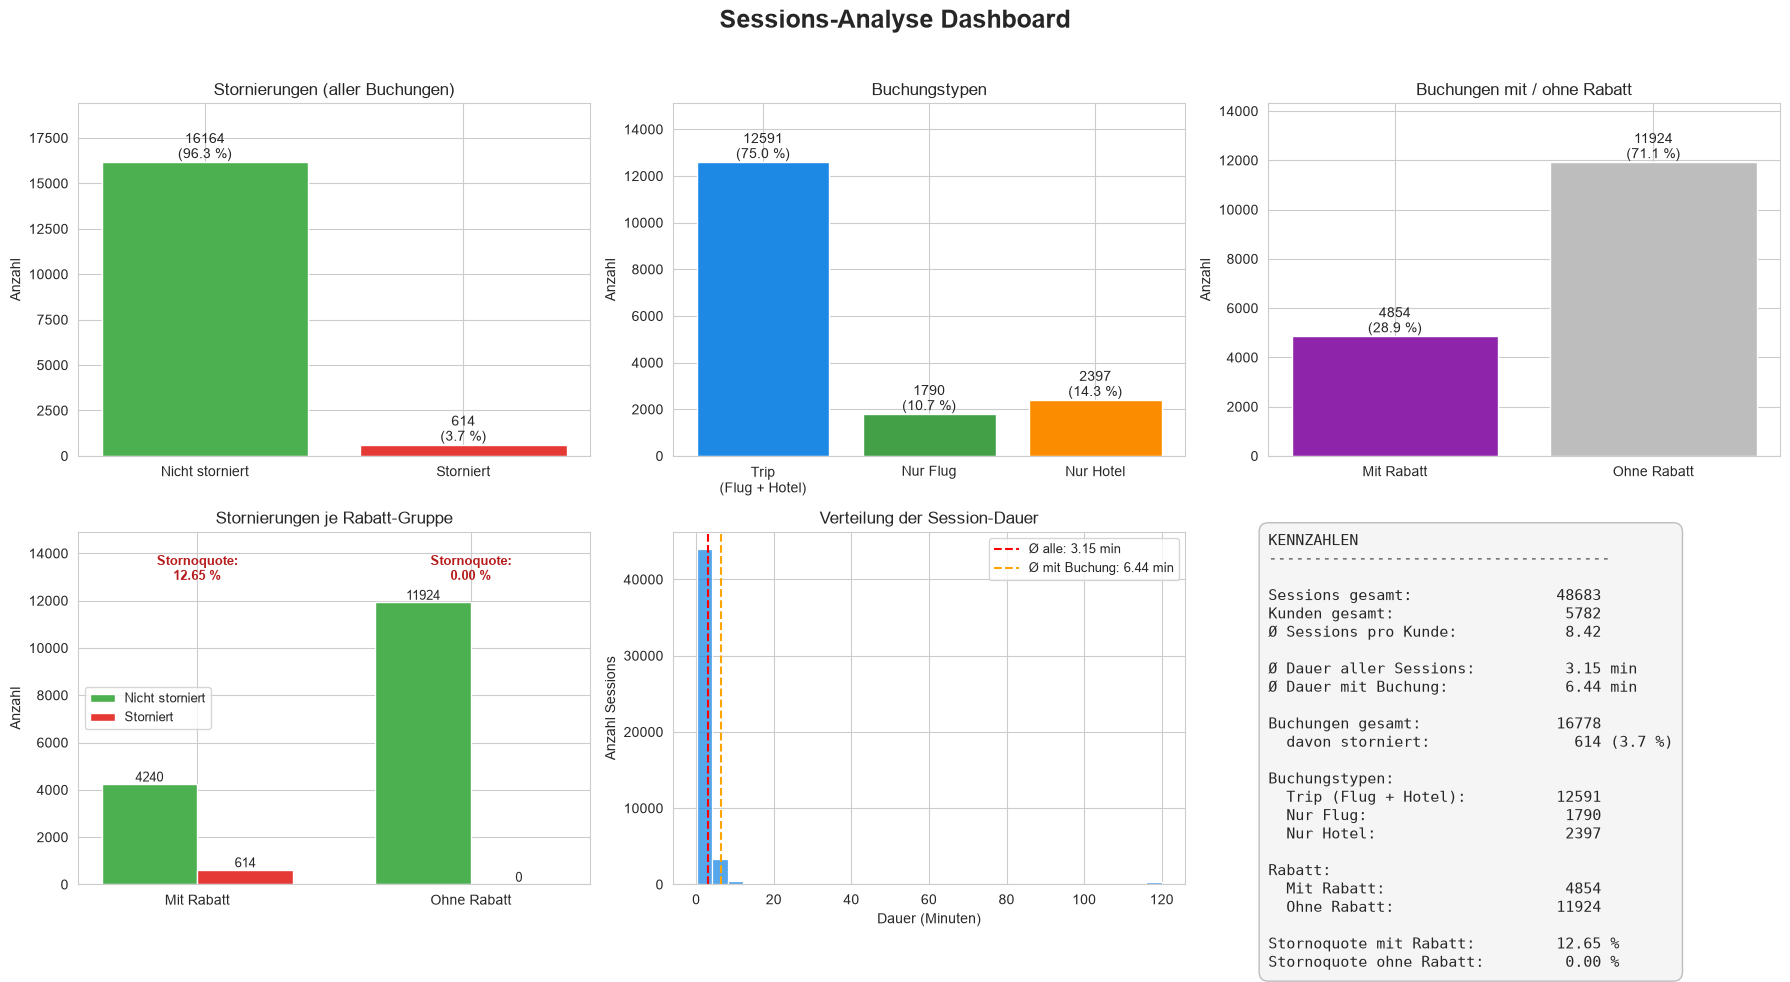

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Datumsspalten konvertieren (mit "mixed" wegen gemischter Formate)
df_sessions["session_start"] = pd.to_datetime(df_sessions["session_start"], format="mixed")
df_sessions["session_end"]   = pd.to_datetime(df_sessions["session_end"],   format="mixed")

# Missing Values ersetzen
df_sessions["flight_discount_amount"] = df_sessions["flight_discount_amount"].fillna(0)
df_sessions["hotel_discount_amount"]  = df_sessions["hotel_discount_amount"].fillna(0)
df_sessions["trip_id"]         = df_sessions["trip_id"].fillna("(session ohne buchung)")

# Boolean-Spalten sicherstellen
for col in ["flight_discount", "hotel_discount",
            "flight_booked", "hotel_booked", "cancellation"]:
    df_sessions[col] = df_sessions[col].astype(bool)

# Dauer in Minuten
df_sessions["duration_session"] = (
    (df_sessions["session_end"] - df_sessions["session_start"])
    .dt.total_seconds() / 60
).round(2)


# =========================================================
# 2. KENNZAHLEN BERECHNEN
# =========================================================

# --- Sessions pro Kunde ---
sessions_pro_kunde = df_sessions.groupby("user_id")["session_id"].count()
avg_sessions_pro_kunde = sessions_pro_kunde.mean()

# --- Durchschnittliche Dauer ---
avg_dauer_alle = df_sessions["duration_session"].mean()

sessions_mit_buchung = df_sessions[
    (df_sessions["flight_booked"]) | (df_sessions["hotel_booked"])
]
avg_dauer_buchung = sessions_mit_buchung["duration_session"].mean()

# --- Buchungen ---
buchungen = df_sessions[
    (df_sessions["flight_booked"]) | (df_sessions["hotel_booked"])
].copy()

gesamt_buchungen = len(buchungen)
storniert        = (buchungen["cancellation"]).sum()
nicht_storniert  = gesamt_buchungen - storniert

# --- Buchungstypen ---
trip_beide = ((buchungen["flight_booked"]) & (buchungen["hotel_booked"])).sum()
nur_flug   = ((buchungen["flight_booked"]) & (~buchungen["hotel_booked"])).sum()
nur_hotel  = ((~buchungen["flight_booked"]) & (buchungen["hotel_booked"])).sum()

# --- Rabatt ---
buchungen["hat_rabatt"] = buchungen["flight_discount"] | buchungen["hotel_discount"]

mit_rabatt  = buchungen[buchungen["hat_rabatt"]]
ohne_rabatt = buchungen[~buchungen["hat_rabatt"]]

gesamt_mit   = len(mit_rabatt)
gesamt_ohne  = len(ohne_rabatt)
storn_mit    = mit_rabatt["cancellation"].sum()
storn_ohne   = ohne_rabatt["cancellation"].sum()
nicht_storn_mit  = gesamt_mit  - storn_mit
nicht_storn_ohne = gesamt_ohne - storn_ohne


# =========================================================
# 3. DASHBOARD ERSTELLEN (2x3 Grid)
# =========================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Sessions-Analyse Dashboard", fontsize=18, fontweight="bold")

# ---------------------------------------------------------
# Plot 1: Storniert vs. Nicht storniert (bezogen auf Buchungen)
# ---------------------------------------------------------
ax = axes[0, 0]
labels = ["Nicht storniert", "Storniert"]
werte  = [nicht_storniert, storniert]
farben = ["#4CAF50", "#E53935"]
bars = ax.bar(labels, werte, color=farben)
for b, w in zip(bars, werte):
    p = w / gesamt_buchungen * 100
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{w}\n({p:.1f} %)", ha="center", va="bottom", fontsize=10)
ax.set_title("Stornierungen (aller Buchungen)")
ax.set_ylabel("Anzahl")
ax.set_ylim(0, max(werte) * 1.2)

# ---------------------------------------------------------
# Plot 2: Buchungstypen
# ---------------------------------------------------------
ax = axes[0, 1]
labels = ["Trip\n(Flug + Hotel)", "Nur Flug", "Nur Hotel"]
werte  = [trip_beide, nur_flug, nur_hotel]
farben = ["#1E88E5", "#43A047", "#FB8C00"]
bars = ax.bar(labels, werte, color=farben)
for b, w in zip(bars, werte):
    p = w / gesamt_buchungen * 100
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{w}\n({p:.1f} %)", ha="center", va="bottom", fontsize=10)
ax.set_title("Buchungstypen")
ax.set_ylabel("Anzahl")
ax.set_ylim(0, max(werte) * 1.2)

# ---------------------------------------------------------
# Plot 3: Mit Rabatt vs. Ohne Rabatt
# ---------------------------------------------------------
ax = axes[0, 2]
labels = ["Mit Rabatt", "Ohne Rabatt"]
werte  = [gesamt_mit, gesamt_ohne]
farben = ["#8E24AA", "#BDBDBD"]
bars = ax.bar(labels, werte, color=farben)
for b, w in zip(bars, werte):
    p = w / gesamt_buchungen * 100
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{w}\n({p:.1f} %)", ha="center", va="bottom", fontsize=10)
ax.set_title("Buchungen mit / ohne Rabatt")
ax.set_ylabel("Anzahl")
ax.set_ylim(0, max(werte) * 1.2)

# ---------------------------------------------------------
# Plot 4: Stornierungen je Rabatt-Gruppe (gruppiert)
# ---------------------------------------------------------
ax = axes[1, 0]
kategorien = ["Mit Rabatt", "Ohne Rabatt"]
x = np.arange(len(kategorien))
breite = 0.35

b1 = ax.bar(x - breite/2, [nicht_storn_mit, nicht_storn_ohne],
            breite, label="Nicht storniert", color="#4CAF50")
b2 = ax.bar(x + breite/2, [storn_mit, storn_ohne],
            breite, label="Storniert", color="#E53935")

for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{int(b.get_height())}", ha="center", va="bottom", fontsize=9)

for i, (st, ges) in enumerate(zip([storn_mit, storn_ohne],
                                   [gesamt_mit, gesamt_ohne])):
    ax.text(x[i], max(nicht_storn_mit, nicht_storn_ohne) * 1.08,
            f"Stornoquote:\n{st/ges*100:.2f} %",
            ha="center", fontsize=9, fontweight="bold", color="#B71C1C")

ax.set_xticks(x)
ax.set_xticklabels(kategorien)
ax.set_title("Stornierungen je Rabatt-Gruppe")
ax.set_ylabel("Anzahl")
ax.set_ylim(0, max(nicht_storn_mit, nicht_storn_ohne) * 1.25)
ax.legend(fontsize=9)

# ---------------------------------------------------------
# Plot 5: Verteilung der Session-Dauer (Histogramm)
# ---------------------------------------------------------
ax = axes[1, 1]
sns.histplot(df_sessions["duration_session"], bins=30,
             color="#1E88E5", ax=ax)
ax.axvline(avg_dauer_alle, color="red", linestyle="--",
           label=f"Ø alle: {avg_dauer_alle:.2f} min")
ax.axvline(avg_dauer_buchung, color="orange", linestyle="--",
           label=f"Ø mit Buchung: {avg_dauer_buchung:.2f} min")
ax.set_title("Verteilung der Session-Dauer")
ax.set_xlabel("Dauer (Minuten)")
ax.set_ylabel("Anzahl Sessions")
ax.legend(fontsize=9)

# ---------------------------------------------------------
# Plot 6: Kennzahlen-Übersicht (Text)
# ---------------------------------------------------------
ax = axes[1, 2]
ax.axis("off")
kpi_text = (
    f"KENNZAHLEN\n"
    f"{'-'*38}\n\n"
    f"Sessions gesamt:               {len(df_sessions):>6}\n"
    f"Kunden gesamt:                 {df_sessions['user_id'].nunique():>6}\n"
    f"Ø Sessions pro Kunde:          {avg_sessions_pro_kunde:>6.2f}\n\n"
    f"Ø Dauer aller Sessions:        {avg_dauer_alle:>6.2f} min\n"
    f"Ø Dauer mit Buchung:           {avg_dauer_buchung:>6.2f} min\n\n"
    f"Buchungen gesamt:              {gesamt_buchungen:>6}\n"
    f"  davon storniert:             {storniert:>6} "
    f"({storniert/gesamt_buchungen*100:.1f} %)\n\n"
    f"Buchungstypen:\n"
    f"  Trip (Flug + Hotel):         {trip_beide:>6}\n"
    f"  Nur Flug:                    {nur_flug:>6}\n"
    f"  Nur Hotel:                   {nur_hotel:>6}\n\n"
    f"Rabatt:\n"
    f"  Mit Rabatt:                  {gesamt_mit:>6}\n"
    f"  Ohne Rabatt:                 {gesamt_ohne:>6}\n\n"
    f"Stornoquote mit Rabatt:        {storn_mit/gesamt_mit*100:>6.2f} %\n"
    f"Stornoquote ohne Rabatt:       {storn_ohne/gesamt_ohne*100:>6.2f} %"
)
ax.text(0.0, 1.0, kpi_text, va="top", ha="left",
        family="monospace", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#F5F5F5",
                  edgecolor="#BDBDBD"))
fig.savefig("../report/sessions_dashboard.png", dpi=300, bbox_inches="tight")


#---------speichern-----------
import os
df_sessions.to_csv("../data/preprocessed/sessions_cleaned.csv", index=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Wichtigste Erkenntnisse im Detail
1. Buchungsverhalten
16.778 Buchungen insgesamt, davon 96,3 % nicht storniert und nur 3,7 % storniert.

75 % aller Buchungen sind Trips (Flug + Hotel) — das klassische Kombi-Paket dominiert klar.

Nur 28,9 % der Buchungen erfolgten mit Rabatt, 71,1 % ohne Rabatt.

2. Stornoquote — der entscheidende Unterschied
Gruppe	Stornoquote
Mit Rabatt	12,65 %
Ohne Rabatt	0,00 %
➡️ Alle 614 Stornierungen stammen aus der Gruppe „mit Rabatt". Keine einzige Buchung ohne Rabatt wurde storniert.

3. Session-Dauer
Ø 3,15 Minuten über alle Sessions

Ø 6,44 Minuten bei Sessions mit Buchung (mehr als doppelt so lang)

➡️ Kunden, die tatsächlich buchen, verbringen deutlich mehr Zeit auf der Plattform.

In [10]:
df_flights = pd.read_csv("../data/raw/flights.csv")
df_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,538944-143fc9f3e3b24e738bd2c76d4f9909e4,HOU,seattle,BFI,1,True,2023-06-22 15:00:00,2023-07-01 15:00:00,1,Kenmore Air,47.530,-122.302,565.52
1,572669-d956a76b03d7408887a99e9893fac794,YWG,chicago,UGN,1,True,2023-06-28 08:00:00,2023-07-01 08:00:00,0,Ryanair,41.786,-87.752,192.71
2,643714-3a28904b60e343ce8d51f014d0d7e326,MDW,cairo,CAI,2,True,2023-12-29 09:00:00,2024-01-09 09:00:00,1,Egyptair,30.122,31.406,3663.19
3,534360-0e212e5f96bf438f84d7faf19dce2cb5,YUL,phoenix,PHX,1,True,2023-06-24 12:00:00,2023-06-29 12:00:00,0,American Airlines,33.535,-112.383,687.39
4,597498-dce865472c0a4f52be79cf9861852ed9,YXU,vancouver,YVR,1,True,2023-06-24 07:00:00,2023-06-26 07:00:00,0,Delta Air Lines,49.195,-123.182,566.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,540302-67485efc58aa4505911990af9c0d727e,LOU,phoenix,LUF,1,True,2023-06-16 15:00:00,2023-06-19 15:00:00,1,Delta Air Lines,33.535,-112.383,416.34
13763,561326-3f324b87b92649cc81eab7b07dc10d58,MSY,fort worth,FTW,1,True,2023-06-19 07:00:00,2023-06-24 07:00:00,1,American Airlines,32.820,-97.362,137.14
13764,523866-f08554b574654170906c8d033da14ddd,YKZ,los angeles,LAX,1,True,2023-06-18 16:00:00,2023-06-22 16:00:00,0,Delta Air Lines,33.942,-118.408,638.29
13765,546130-8a0ca36e73d344bcb6ae7661c55ad760,BFL,baltimore,BWI,1,True,2023-06-18 14:00:00,2023-06-26 14:00:00,2,AirTran Airways,39.175,-76.668,668.85


In [11]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 13767 entries, 0 to 13766
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  13767 non-null  str    
 1   origin_airport           13767 non-null  str    
 2   destination              13767 non-null  str    
 3   destination_airport      13767 non-null  str    
 4   seats                    13767 non-null  int64  
 5   return_flight_booked     13767 non-null  bool   
 6   departure_time           13767 non-null  str    
 7   return_time              13172 non-null  str    
 8   checked_bags             13767 non-null  int64  
 9   trip_airline             13767 non-null  str    
 10  destination_airport_lat  13767 non-null  float64
 11  destination_airport_lon  13767 non-null  float64
 12  base_fare_usd            13767 non-null  float64
dtypes: bool(1), float64(3), int64(2), str(7)
memory usage: 1.3 MB


In [12]:
df_flights.isna().sum()

trip_id                      0
origin_airport               0
destination                  0
destination_airport          0
seats                        0
return_flight_booked         0
departure_time               0
return_time                595
checked_bags                 0
trip_airline                 0
destination_airport_lat      0
destination_airport_lon      0
base_fare_usd                0
dtype: int64

In [13]:
df_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,538944-143fc9f3e3b24e738bd2c76d4f9909e4,HOU,seattle,BFI,1,True,2023-06-22 15:00:00,2023-07-01 15:00:00,1,Kenmore Air,47.530,-122.302,565.52
1,572669-d956a76b03d7408887a99e9893fac794,YWG,chicago,UGN,1,True,2023-06-28 08:00:00,2023-07-01 08:00:00,0,Ryanair,41.786,-87.752,192.71
2,643714-3a28904b60e343ce8d51f014d0d7e326,MDW,cairo,CAI,2,True,2023-12-29 09:00:00,2024-01-09 09:00:00,1,Egyptair,30.122,31.406,3663.19
3,534360-0e212e5f96bf438f84d7faf19dce2cb5,YUL,phoenix,PHX,1,True,2023-06-24 12:00:00,2023-06-29 12:00:00,0,American Airlines,33.535,-112.383,687.39
4,597498-dce865472c0a4f52be79cf9861852ed9,YXU,vancouver,YVR,1,True,2023-06-24 07:00:00,2023-06-26 07:00:00,0,Delta Air Lines,49.195,-123.182,566.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,540302-67485efc58aa4505911990af9c0d727e,LOU,phoenix,LUF,1,True,2023-06-16 15:00:00,2023-06-19 15:00:00,1,Delta Air Lines,33.535,-112.383,416.34
13763,561326-3f324b87b92649cc81eab7b07dc10d58,MSY,fort worth,FTW,1,True,2023-06-19 07:00:00,2023-06-24 07:00:00,1,American Airlines,32.820,-97.362,137.14
13764,523866-f08554b574654170906c8d033da14ddd,YKZ,los angeles,LAX,1,True,2023-06-18 16:00:00,2023-06-22 16:00:00,0,Delta Air Lines,33.942,-118.408,638.29
13765,546130-8a0ca36e73d344bcb6ae7661c55ad760,BFL,baltimore,BWI,1,True,2023-06-18 14:00:00,2023-06-26 14:00:00,2,AirTran Airways,39.175,-76.668,668.85


In [14]:
import os

df_flights['departure_time'] = pd.to_datetime(df_flights['departure_time'])
df_flights['return_time']    = pd.to_datetime(df_flights['return_time'])

# --- Datum / Zeit ---
df_flights['departure_month']   = df_flights['departure_time'].dt.month_name()
df_flights['departure_weekday'] = df_flights['departure_time'].dt.day_name()
df_flights['departure_hour']    = df_flights['departure_time'].dt.hour
df_flights['departure_year']    = df_flights['departure_time'].dt.year

# --- Trip-Dauer (nur für Round-Trips, sonst NaN) ---
df_flights['trip_duration_days'] = (
    df_flights['return_time'] - df_flights['departure_time']
).dt.days

# --- Route als String ---
df_flights['route'] = df_flights['origin_airport'] + ' → ' + df_flights['destination_airport']

# --- Preis-Kategorien ---
df_flights['price_category'] = pd.cut(
    df_flights['base_fare_usd'],
    bins=[0, 200, 500, 1000, np.inf],
    labels=['günstig (<200)', 'mittel (200-500)', 'teuer (500-1000)', 'sehr teuer (>1000)']
)
#---- One Way Ticket ------
df_flights['onewayflug'] = df_flights['return_flight_booked'] == False

# --- Wochenende-Flag ---
df_flights['is_weekend'] = df_flights['departure_weekday'].isin(['Saturday', 'Sunday'])

#----speichern -------------
df_flights.to_csv("../data/preprocessed/flights_cleaned.csv", index=False)




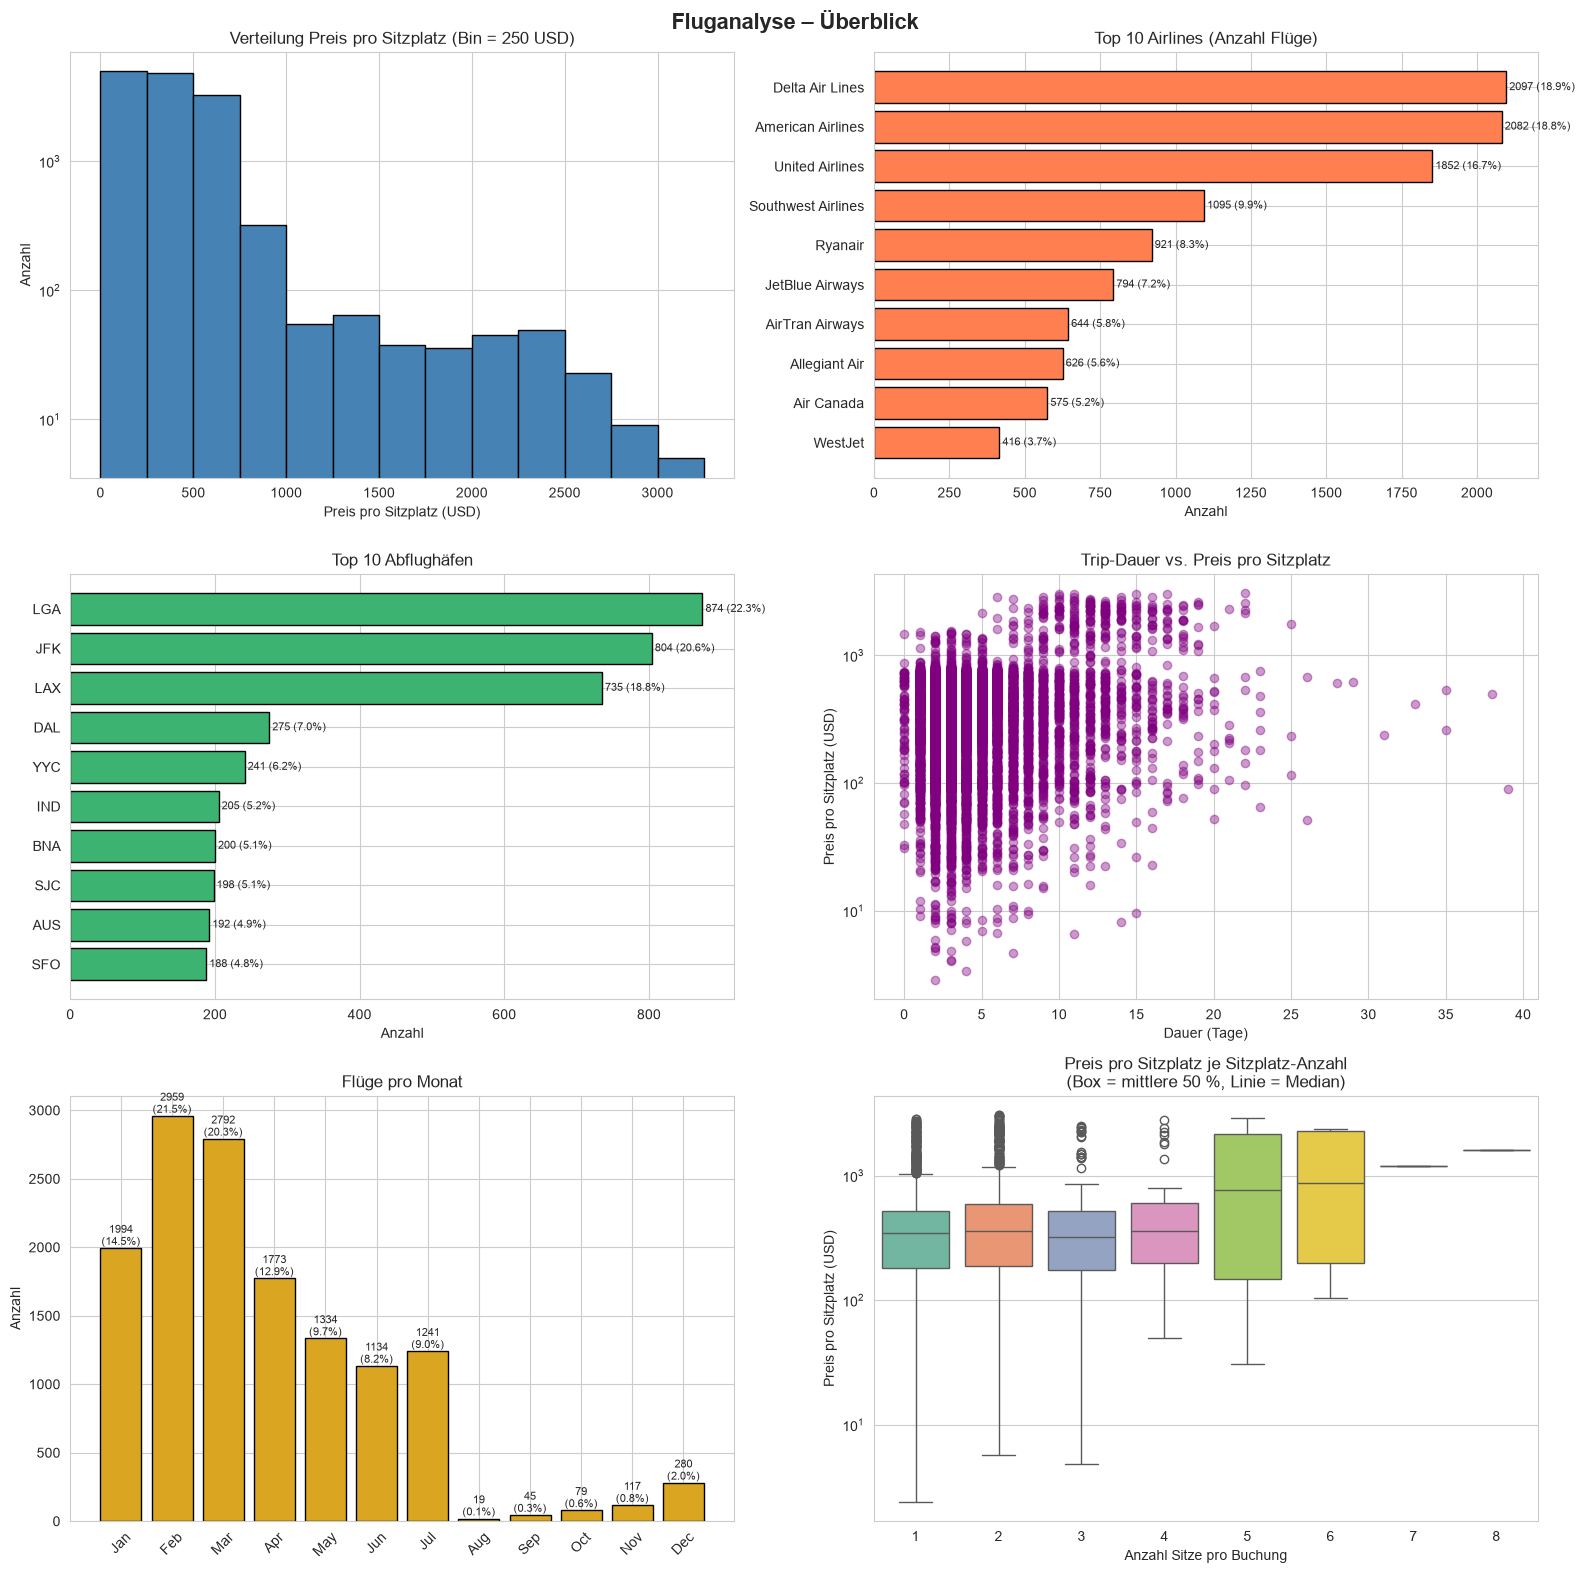

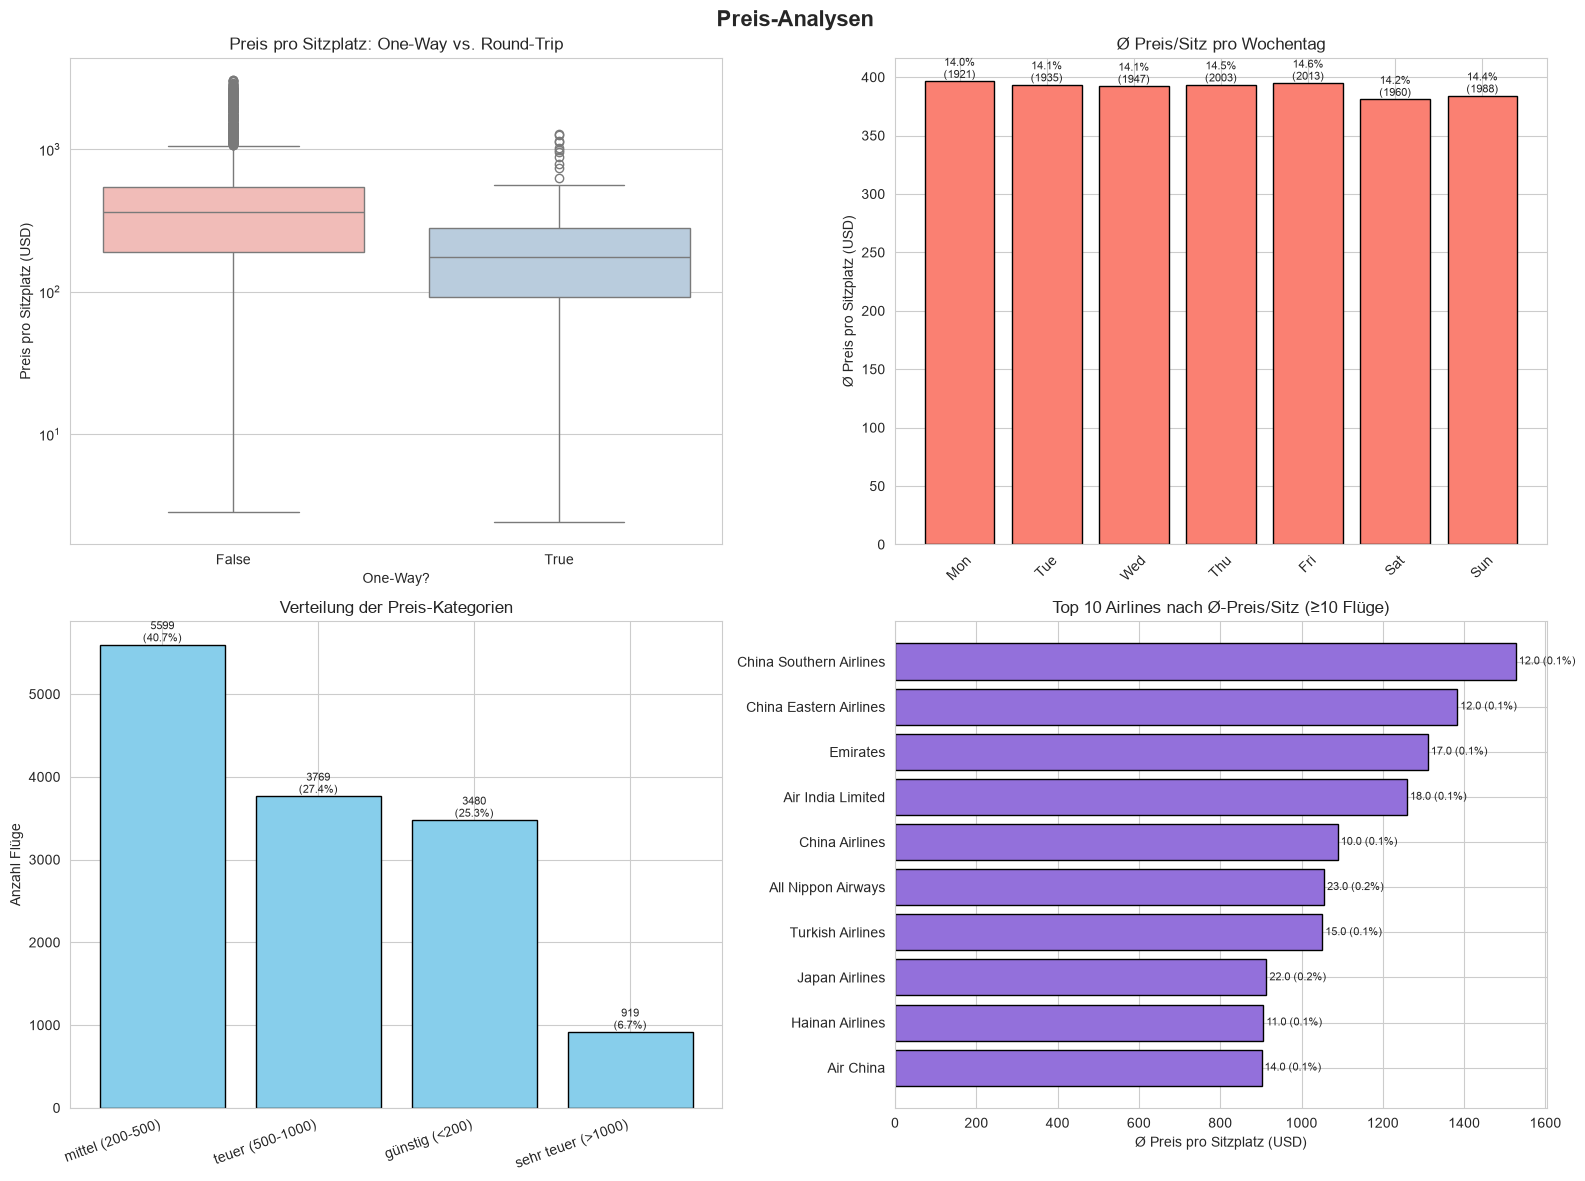

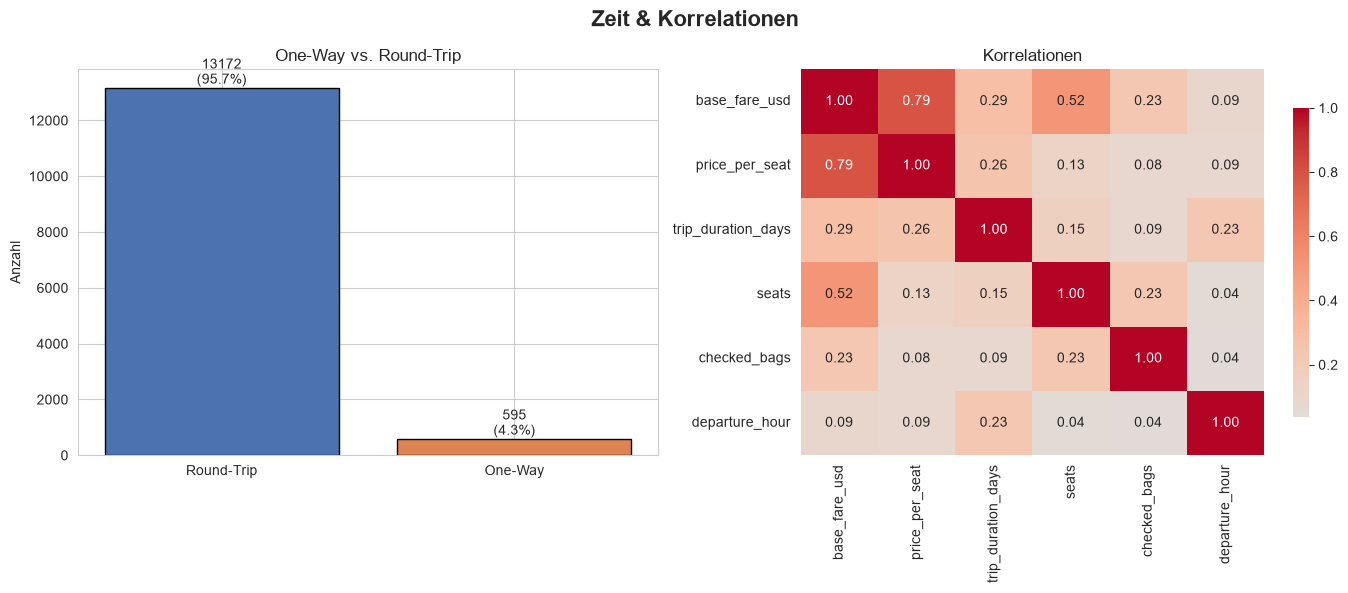

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df_flights['price_per_seat'] = df_flights['base_fare_usd'] / df_flights['seats']

# Sortier-Reihenfolgen
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order   = ['January','February','March','April','May','June',
                 'July','August','September','October','November','December']


# ------------------------------------------------------------
# Hilfsfunktion: Prozent-Labels
# ------------------------------------------------------------
def add_pct_labels(ax, values, orientation='v', fontsize=8):
    total = sum(values)
    for i, v in enumerate(values):
        pct = v / total * 100
        label = f"{v}\n({pct:.1f}%)"
        if orientation == 'v':
            ax.text(i, v, label, ha='center', va='bottom', fontsize=fontsize)
        else:
            ax.text(v, i, f" {v} ({pct:.1f}%)", va='center', fontsize=fontsize)


# ------------------------------------------------------------
# FIGUR 1: Überblick
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Fluganalyse – Überblick', fontsize=16, fontweight='bold')

# (1) Histogramm Preis pro Sitzplatz – Bin-Breite 250 USD
pmin = 0
pmax = np.ceil(df_flights['price_per_seat'].max() / 250) * 250
bins = np.arange(pmin, pmax + 250, 250)
axes[0, 0].hist(df_flights['price_per_seat'].dropna(),
                bins=bins, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Verteilung Preis pro Sitzplatz (Bin = 250 USD)')
axes[0, 0].set_xlabel('Preis pro Sitzplatz (USD)')
axes[0, 0].set_ylabel('Anzahl')
axes[0, 0].set_yscale('log')

# (2) Top 10 Airlines + %
top_airlines = df_flights['trip_airline'].value_counts().head(10)
axes[0, 1].barh(top_airlines.index, top_airlines.values,
                color='coral', edgecolor='black')
axes[0, 1].set_title('Top 10 Airlines (Anzahl Flüge)')
axes[0, 1].set_xlabel('Anzahl')
axes[0, 1].invert_yaxis()
add_pct_labels(axes[0, 1], top_airlines.values, orientation='h')

# (3) Top 10 Abflughäfen + %
top_origin = df_flights['origin_airport'].value_counts().head(10)
axes[1, 0].barh(top_origin.index, top_origin.values,
                color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Top 10 Abflughäfen')
axes[1, 0].set_xlabel('Anzahl')
axes[1, 0].invert_yaxis()
add_pct_labels(axes[1, 0], top_origin.values, orientation='h')

# (4) Trip-Dauer vs. Preis pro Sitzplatz
axes[1, 1].scatter(df_flights['trip_duration_days'],
                   df_flights['price_per_seat'],
                   alpha=0.4, color='purple')
axes[1, 1].set_title('Trip-Dauer vs. Preis pro Sitzplatz')
axes[1, 1].set_xlabel('Dauer (Tage)')
axes[1, 1].set_ylabel('Preis pro Sitzplatz (USD)')
axes[1, 1].set_yscale('log')

# (5) Flüge pro Monat + %
monthly = df_flights.groupby('departure_month').size().reindex(month_order)
axes[2, 0].bar(range(len(monthly)), monthly.values,
               color='goldenrod', edgecolor='black')
axes[2, 0].set_xticks(range(len(monthly)))
axes[2, 0].set_xticklabels([m[:3] for m in monthly.index], rotation=45)
axes[2, 0].set_title('Flüge pro Monat')
axes[2, 0].set_ylabel('Anzahl')
add_pct_labels(axes[2, 0], monthly.values)

# (6) Sitzplätze vs. Preis pro Sitzplatz (Boxplot)
sns.boxplot(x='seats', y='price_per_seat', data=df_flights,
            ax=axes[2, 1], hue='seats', palette='Set2', legend=False)
axes[2, 1].set_title('Preis pro Sitzplatz je Sitzplatz-Anzahl\n'
                     '(Box = mittlere 50 %, Linie = Median)')
axes[2, 1].set_xlabel('Anzahl Sitze pro Buchung')
axes[2, 1].set_ylabel('Preis pro Sitzplatz (USD)')
axes[2, 1].set_yscale('log')

fig.savefig("../report/Flights_Daschboard_1.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FIGUR 2: Preis-Analysen
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Preis-Analysen', fontsize=16, fontweight='bold')

# (1) One-Way vs. Round-Trip (Preis/Sitz)
sns.boxplot(x='onewayflug', y='price_per_seat', data=df_flights,
            ax=axes[0, 0], hue='onewayflug',
            palette='Pastel1', legend=False)
axes[0, 0].set_title('Preis pro Sitzplatz: One-Way vs. Round-Trip')
axes[0, 0].set_xlabel('One-Way?')
axes[0, 0].set_ylabel('Preis pro Sitzplatz (USD)')
axes[0, 0].set_yscale('log')

# (2) Ø Preis/Sitz pro Wochentag + %
weekday_price = (df_flights.groupby('departure_weekday')['price_per_seat']
                           .mean().reindex(weekday_order))
weekday_count = (df_flights.groupby('departure_weekday')
                           .size().reindex(weekday_order))
axes[0, 1].bar(range(len(weekday_price)), weekday_price.values,
               color='salmon', edgecolor='black')
axes[0, 1].set_xticks(range(len(weekday_price)))
axes[0, 1].set_xticklabels([d[:3] for d in weekday_price.index], rotation=45)
axes[0, 1].set_title('Ø Preis/Sitz pro Wochentag')
axes[0, 1].set_ylabel('Ø Preis pro Sitzplatz (USD)')
total_flights = weekday_count.sum()
for i, (price, cnt) in enumerate(zip(weekday_price.values, weekday_count.values)):
    pct = cnt / total_flights * 100
    axes[0, 1].text(i, price, f"{pct:.1f}%\n({cnt})",
                    ha='center', va='bottom', fontsize=8)

# (3) Preis-Kategorien + %
cat_counts = df_flights['price_category'].value_counts()
axes[1, 0].bar(range(len(cat_counts)), cat_counts.values,
               color='skyblue', edgecolor='black')
axes[1, 0].set_xticks(range(len(cat_counts)))
axes[1, 0].set_xticklabels(cat_counts.index, rotation=20, ha='right')
axes[1, 0].set_title('Verteilung der Preis-Kategorien')
axes[1, 0].set_ylabel('Anzahl Flüge')
add_pct_labels(axes[1, 0], cat_counts.values)

# (4) Top 10 Airlines nach Ø-Preis/Sitz + %
airline_stats = (df_flights.groupby('trip_airline')
                           .agg(anzahl=('price_per_seat', 'count'),
                                durchschnitt=('price_per_seat', 'mean'))
                           .query('anzahl >= 10')
                           .sort_values('durchschnitt', ascending=False)
                           .head(10))
axes[1, 1].barh(airline_stats.index, airline_stats['durchschnitt'],
                color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Top 10 Airlines nach Ø-Preis/Sitz (≥10 Flüge)')
axes[1, 1].set_xlabel('Ø Preis pro Sitzplatz (USD)')
axes[1, 1].invert_yaxis()
total_all = len(df_flights)
for i, (name, row) in enumerate(airline_stats.iterrows()):
    pct = row['anzahl'] / total_all * 100
    axes[1, 1].text(row['durchschnitt'], i,
                    f" {row['anzahl']} ({pct:.1f}%)",
                    va='center', fontsize=8)

fig.savefig("../report/Flights_Daschboard_2.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FIGUR 3: Zeit & Korrelationen (ohne Ø Preis/Sitz pro Monat)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Zeit & Korrelationen', fontsize=16, fontweight='bold')

# (1) One-Way vs. Round-Trip (Anzahl)
trip_counts = df_flights['onewayflug'].value_counts().sort_index()
labels = ['Round-Trip', 'One-Way']
axes[0].bar(labels, trip_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('One-Way vs. Round-Trip')
axes[0].set_ylabel('Anzahl')
total = trip_counts.sum()
for i, v in enumerate(trip_counts.values):
    pct = v / total * 100
    axes[0].text(i, v, f"{v}\n({pct:.1f}%)",
                 ha='center', va='bottom', fontsize=10)

# (2) Korrelations-Heatmap
num_cols = ['base_fare_usd', 'price_per_seat', 'trip_duration_days',
            'seats', 'checked_bags', 'departure_hour']
corr = df_flights[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Korrelationen')

fig.savefig("../report/Flights_Daschboard_3.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

📊 Die wichtigsten Erkenntnisse im Detail
➡️ Kernaussagen:
    1- Ein paar große Player dominieren — kleinere Airlines und Regionalflughäfen spielen eine Nebenrolle.
    2- Reisende buchen fast immer hin und zurück — One-Way ist die Ausnahme.
    3- Die Mehrheit der Flüge ist bezahlbar, aber es gibt eine kleine Gruppe extrem teurer Flüge.
    4- Round-Trips kosten pro Sitz mehr als das Dreifache — weil sie mehr Flugsegmente enthalten.
    5- Der Buchungstag (Mo–So) spielt kaum eine Rolle. Der Monat zeigt Muster, ist aber durch Ausreißer verzerrt.
    6- Der Gesamtpreis bestimmt den Preis pro Sitz — die Reisedauer oder Sitzplatzanzahl kaum.
    7- Die meisten Flüge starten im Februar (21,5 %), März (20,3 %) und Januar (14,5 %) — die Sommermonate spielen dagegen eine kleinere Rolle.
    8- Der Ø-Preis schwankt stark: Juli ist am günstigsten (~360 USD), Oktober am teuersten (~1.100 USD) — aber Vorsicht: Oktober basiert auf wenigen Datenpunkten.
    9- base_fare_usd und price_per_seat korrelieren stark (r = 0,79), während trip_duration_days und price_per_seat nur schwach (r = 0,26) zusammenhängen.


In [ ]:
df_hotels = pd.read_csv("../data/raw/hotels.csv")
df_hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,379543-786b5bc990ab42348075f170807f4625,Four Seasons - tucson,1,1,2022-11-04 16:27:07.020,2022-11-06 11:00:00,289.0
1,408551-35b342c868fa4dcfae23554edc29491e,Extended Stay - new york,3,2,2022-11-20 15:29:05.775,2022-11-24 11:00:00,304.0
2,417679-624d84164bc443e6bfc876d4a84d358c,Hyatt - louisville,2,3,2022-11-26 10:18:43.830,2022-11-28 11:00:00,400.0
3,416319-1b7b31b88d834e94813e68865cbc87cf,NH Hotel - phoenix,2,1,2022-12-03 18:20:46.995,2022-12-06 11:00:00,107.0
4,426478-9e3f1753141b4c3c82d3164029d2eecb,Shangri-La - detroit,14,1,2023-01-18 09:19:52.005,2023-02-01 11:00:00,100.0
...,...,...,...,...,...,...,...
14369,528735-40ab1cc1756745c1814b683d2af2e07c,Rosewood - toronto,0,2,2023-07-28 17:02:59.550,2023-07-29 11:00:00,224.0
14370,675594-084fb7964a664f1593002725d0ebce57,Fairmont - houston,2,1,2023-07-25 14:24:00.360,2023-07-28 11:00:00,84.0
14371,638580-a26a38d6775d4d1ca59a0e4a6816c4d1,Wyndham - new york,7,1,2023-07-22 11:00:00.000,2023-07-29 11:00:00,119.0
14372,653640-0f7354c3dc7341899c2097b2cb38049d,Conrad - paris,10,1,2024-03-02 05:12:13.455,2024-03-12 11:00:00,184.0


In [ ]:
# Anzahl der negativen Werte
anzahl_negativ = (df_hotels["nights"] < 0).sum()
print(f"Anzahl negativer Werte in nights: {anzahl_negativ}")

# Optional: auch als Anteil in Prozent
anteil = (df_hotels["nights"] < 0).mean() * 100
print(f"Anteil: {anteil:.2f} %")

Anzahl negativer Werte in nights: 109
Anteil: 0.76 %


Gespeichert: ../data/cleaned/hotels_cleaned.csv
Gespeichert: ../report/Hotels_Cleaning_Dashboard.png


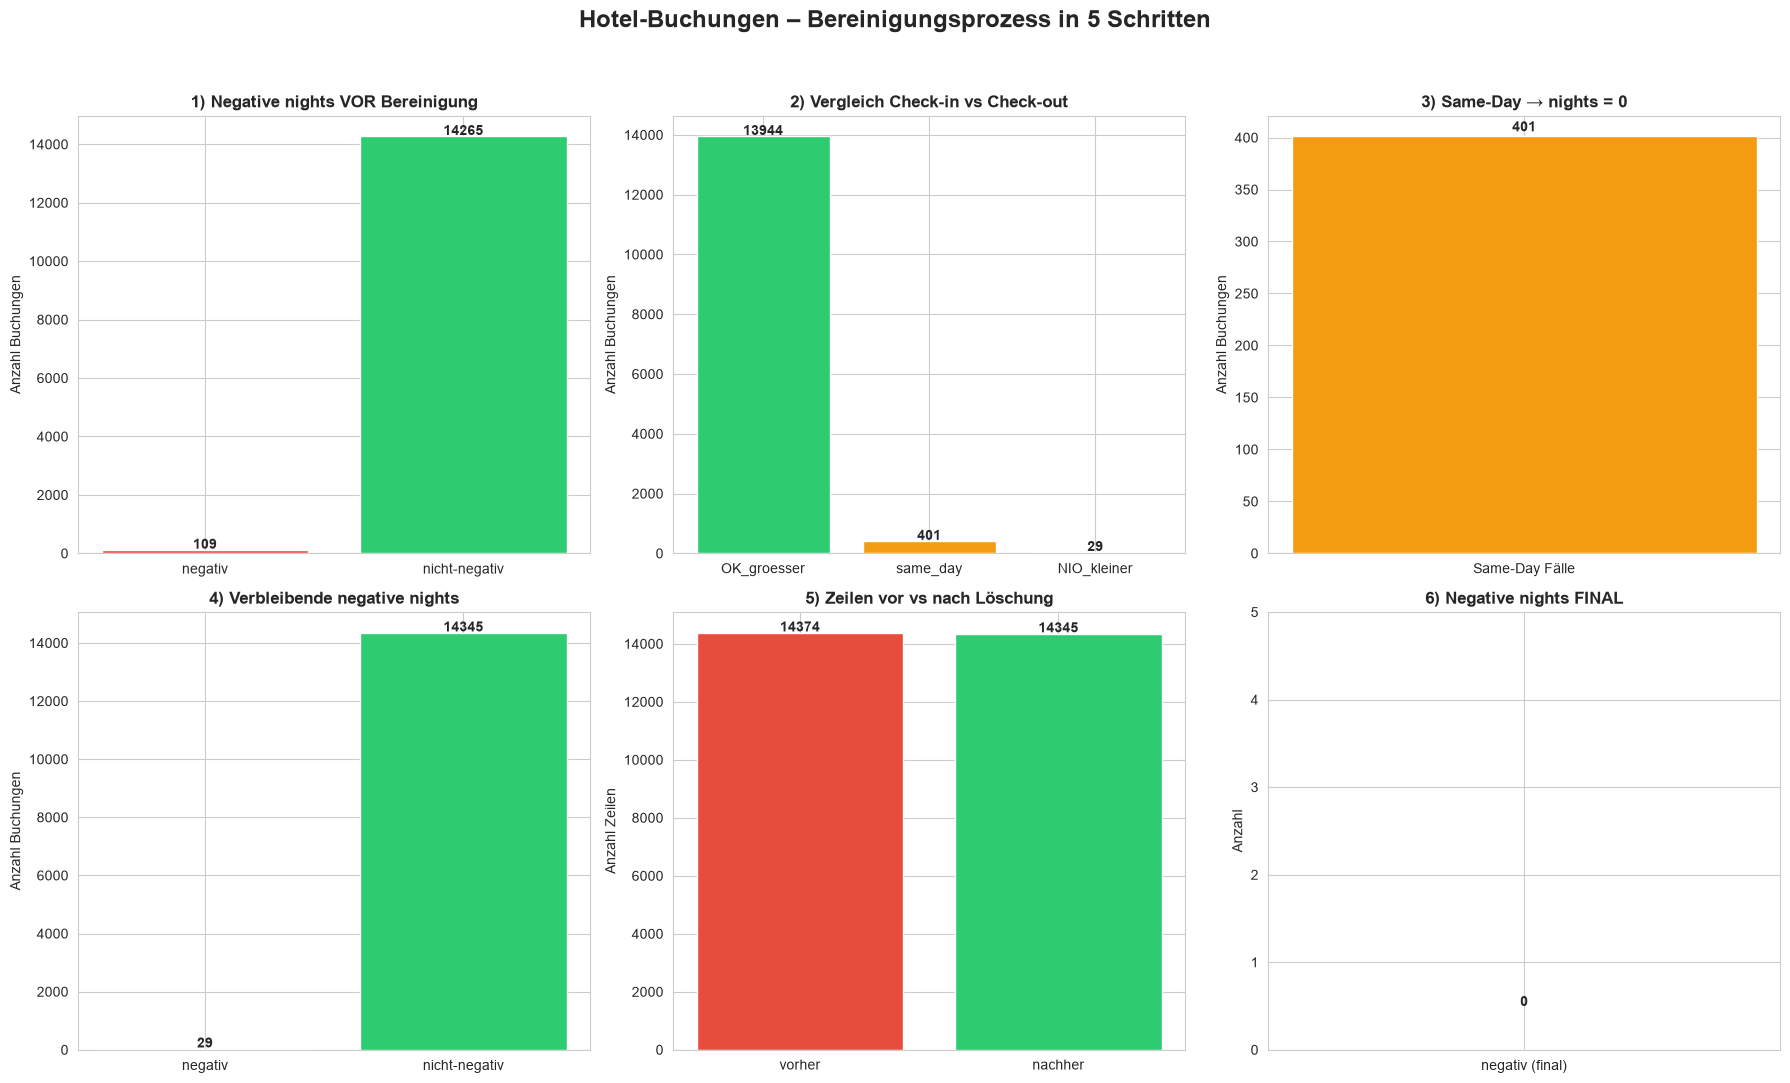

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==================================================================
# 1. DATEN LADEN
# ==================================================================
df_hotels = pd.read_csv("../data/raw/hotels.csv")
df_hotels["check_in_time"]  = pd.to_datetime(df_hotels["check_in_time"])
df_hotels["check_out_time"] = pd.to_datetime(df_hotels["check_out_time"])

sns.set_style("whitegrid")

# ==================================================================
# SCHRITT 1: NEGATIVE NIGHTS VOR ALLEM
# ==================================================================
neg_vorher = (df_hotels["nights"] < 0).sum()
pos_vorher = (df_hotels["nights"] >= 0).sum()

# ==================================================================
# SCHRITT 2: VERGLEICH CHECK_IN vs CHECK_OUT
# ==================================================================
check_in_date  = df_hotels["check_in_time"].dt.date
check_out_date = df_hotels["check_out_time"].dt.date

df_hotels["check_vergleich"] = np.where(
    check_out_date > check_in_date, "OK_groesser",
    np.where(check_out_date < check_in_date, "NIO_kleiner", "same_day")
)

vergleich_counts = df_hotels["check_vergleich"].value_counts()

# ==================================================================
# SCHRITT 3: SAME-DAY → nights = 0
# ==================================================================
same_day_mask = df_hotels["check_vergleich"] == "same_day"
anzahl_same_day = same_day_mask.sum()
df_hotels.loc[same_day_mask, "nights"] = 0

# ==================================================================
# SCHRITT 4: VERBLEIBENDE NEGATIVE NIGHTS
# ==================================================================
neg_nachher = (df_hotels["nights"] < 0).sum()
pos_nachher = (df_hotels["nights"] >= 0).sum()

# ==================================================================
# SCHRITT 5: DIESE LÖSCHEN
# ==================================================================
df_hotels_clean = df_hotels[df_hotels["nights"] >= 0].copy()

neg_final = (df_hotels_clean["nights"] < 0).sum()
zeilen_vorher = len(df_hotels)
zeilen_nachher = len(df_hotels_clean)
geloescht = zeilen_vorher - zeilen_nachher

# ==================================================================
# SPEICHERN DER BEREINIGTEN DATEN
# ==================================================================
os.makedirs("../data/cleaned", exist_ok=True)
df_hotels_clean.to_csv("../data/preprocessed/hotels_cleaned.csv", index=False)
print("Gespeichert: ../data/cleaned/hotels_cleaned.csv")

# ==================================================================
# DASHBOARD – EINE EINZIGE ABBILDUNG (2x3)
# ==================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Hotel-Buchungen – Bereinigungsprozess in 5 Schritten",
             fontsize=17, fontweight="bold")

# ---------- Plot 1: Negative nights VOR Bereinigung ----------
bars = axes[0, 0].bar(["negativ", "nicht-negativ"], [neg_vorher, pos_vorher],
                      color=["#e74c3c", "#2ecc71"])
axes[0, 0].set_title("1) Negative nights VOR Bereinigung", fontweight="bold")
axes[0, 0].set_ylabel("Anzahl Buchungen")
for b, v in zip(bars, [neg_vorher, pos_vorher]):
    axes[0, 0].text(b.get_x() + b.get_width()/2, v + 50, str(v),
                    ha="center", fontweight="bold")

# ---------- Plot 2: Vergleich check_in vs check_out ----------
farben = {"OK_groesser": "#2ecc71", "same_day": "#f39c12", "NIO_kleiner": "#e74c3c"}
bars = axes[0, 1].bar(vergleich_counts.index, vergleich_counts.values,
                      color=[farben[k] for k in vergleich_counts.index])
axes[0, 1].set_title("2) Vergleich Check-in vs Check-out", fontweight="bold")
axes[0, 1].set_ylabel("Anzahl Buchungen")
for b, v in zip(bars, vergleich_counts.values):
    axes[0, 1].text(b.get_x() + b.get_width()/2, v + 50, str(v),
                    ha="center", fontweight="bold")

# ---------- Plot 3: Same-Day → nights = 0 ----------
bars = axes[0, 2].bar(["Same-Day Fälle"], [anzahl_same_day], color="#f39c12")
axes[0, 2].set_title("3) Same-Day → nights = 0", fontweight="bold")
axes[0, 2].set_ylabel("Anzahl Buchungen")
for b in bars:
    axes[0, 2].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                    str(int(b.get_height())), ha="center", fontweight="bold")

# ---------- Plot 4: Verbleibende negative nights ----------
bars = axes[1, 0].bar(["negativ", "nicht-negativ"], [neg_nachher, pos_nachher],
                      color=["#e74c3c", "#2ecc71"])
axes[1, 0].set_title("4) Verbleibende negative nights", fontweight="bold")
axes[1, 0].set_ylabel("Anzahl Buchungen")
for b, v in zip(bars, [neg_nachher, pos_nachher]):
    axes[1, 0].text(b.get_x() + b.get_width()/2, v + 50, str(v),
                    ha="center", fontweight="bold")

# ---------- Plot 5: Zeilen vor vs nach Löschung ----------
bars = axes[1, 1].bar(["vorher", "nachher"], [zeilen_vorher, zeilen_nachher],
                      color=["#e74c3c", "#2ecc71"])
axes[1, 1].set_title("5) Zeilen vor vs nach Löschung", fontweight="bold")
axes[1, 1].set_ylabel("Anzahl Zeilen")
for b, v in zip(bars, [zeilen_vorher, zeilen_nachher]):
    axes[1, 1].text(b.get_x() + b.get_width()/2, v + 50, str(v),
                    ha="center", fontweight="bold")

# ---------- Plot 6: Negative nights FINAL ----------
bars = axes[1, 2].bar(["negativ (final)"], [neg_final], color="#2ecc71")
axes[1, 2].set_title("6) Negative nights FINAL", fontweight="bold")
axes[1, 2].set_ylabel("Anzahl")
axes[1, 2].set_ylim(0, max(5, neg_final + 5))
axes[1, 2].text(0, neg_final + 0.5, str(neg_final),
                ha="center", fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ==================================================================
# SPEICHERN DER FIGUR
# ==================================================================
os.makedirs("../report", exist_ok=True)
fig.savefig("../report/Hotels_Cleaning_Dashboard.png", dpi=150, bbox_inches="tight")
print("Gespeichert: ../report/Hotels_Cleaning_Dashboard.png")

plt.show()

Gespeichert: ../report/Hotels_Analysis_Dashboard.png


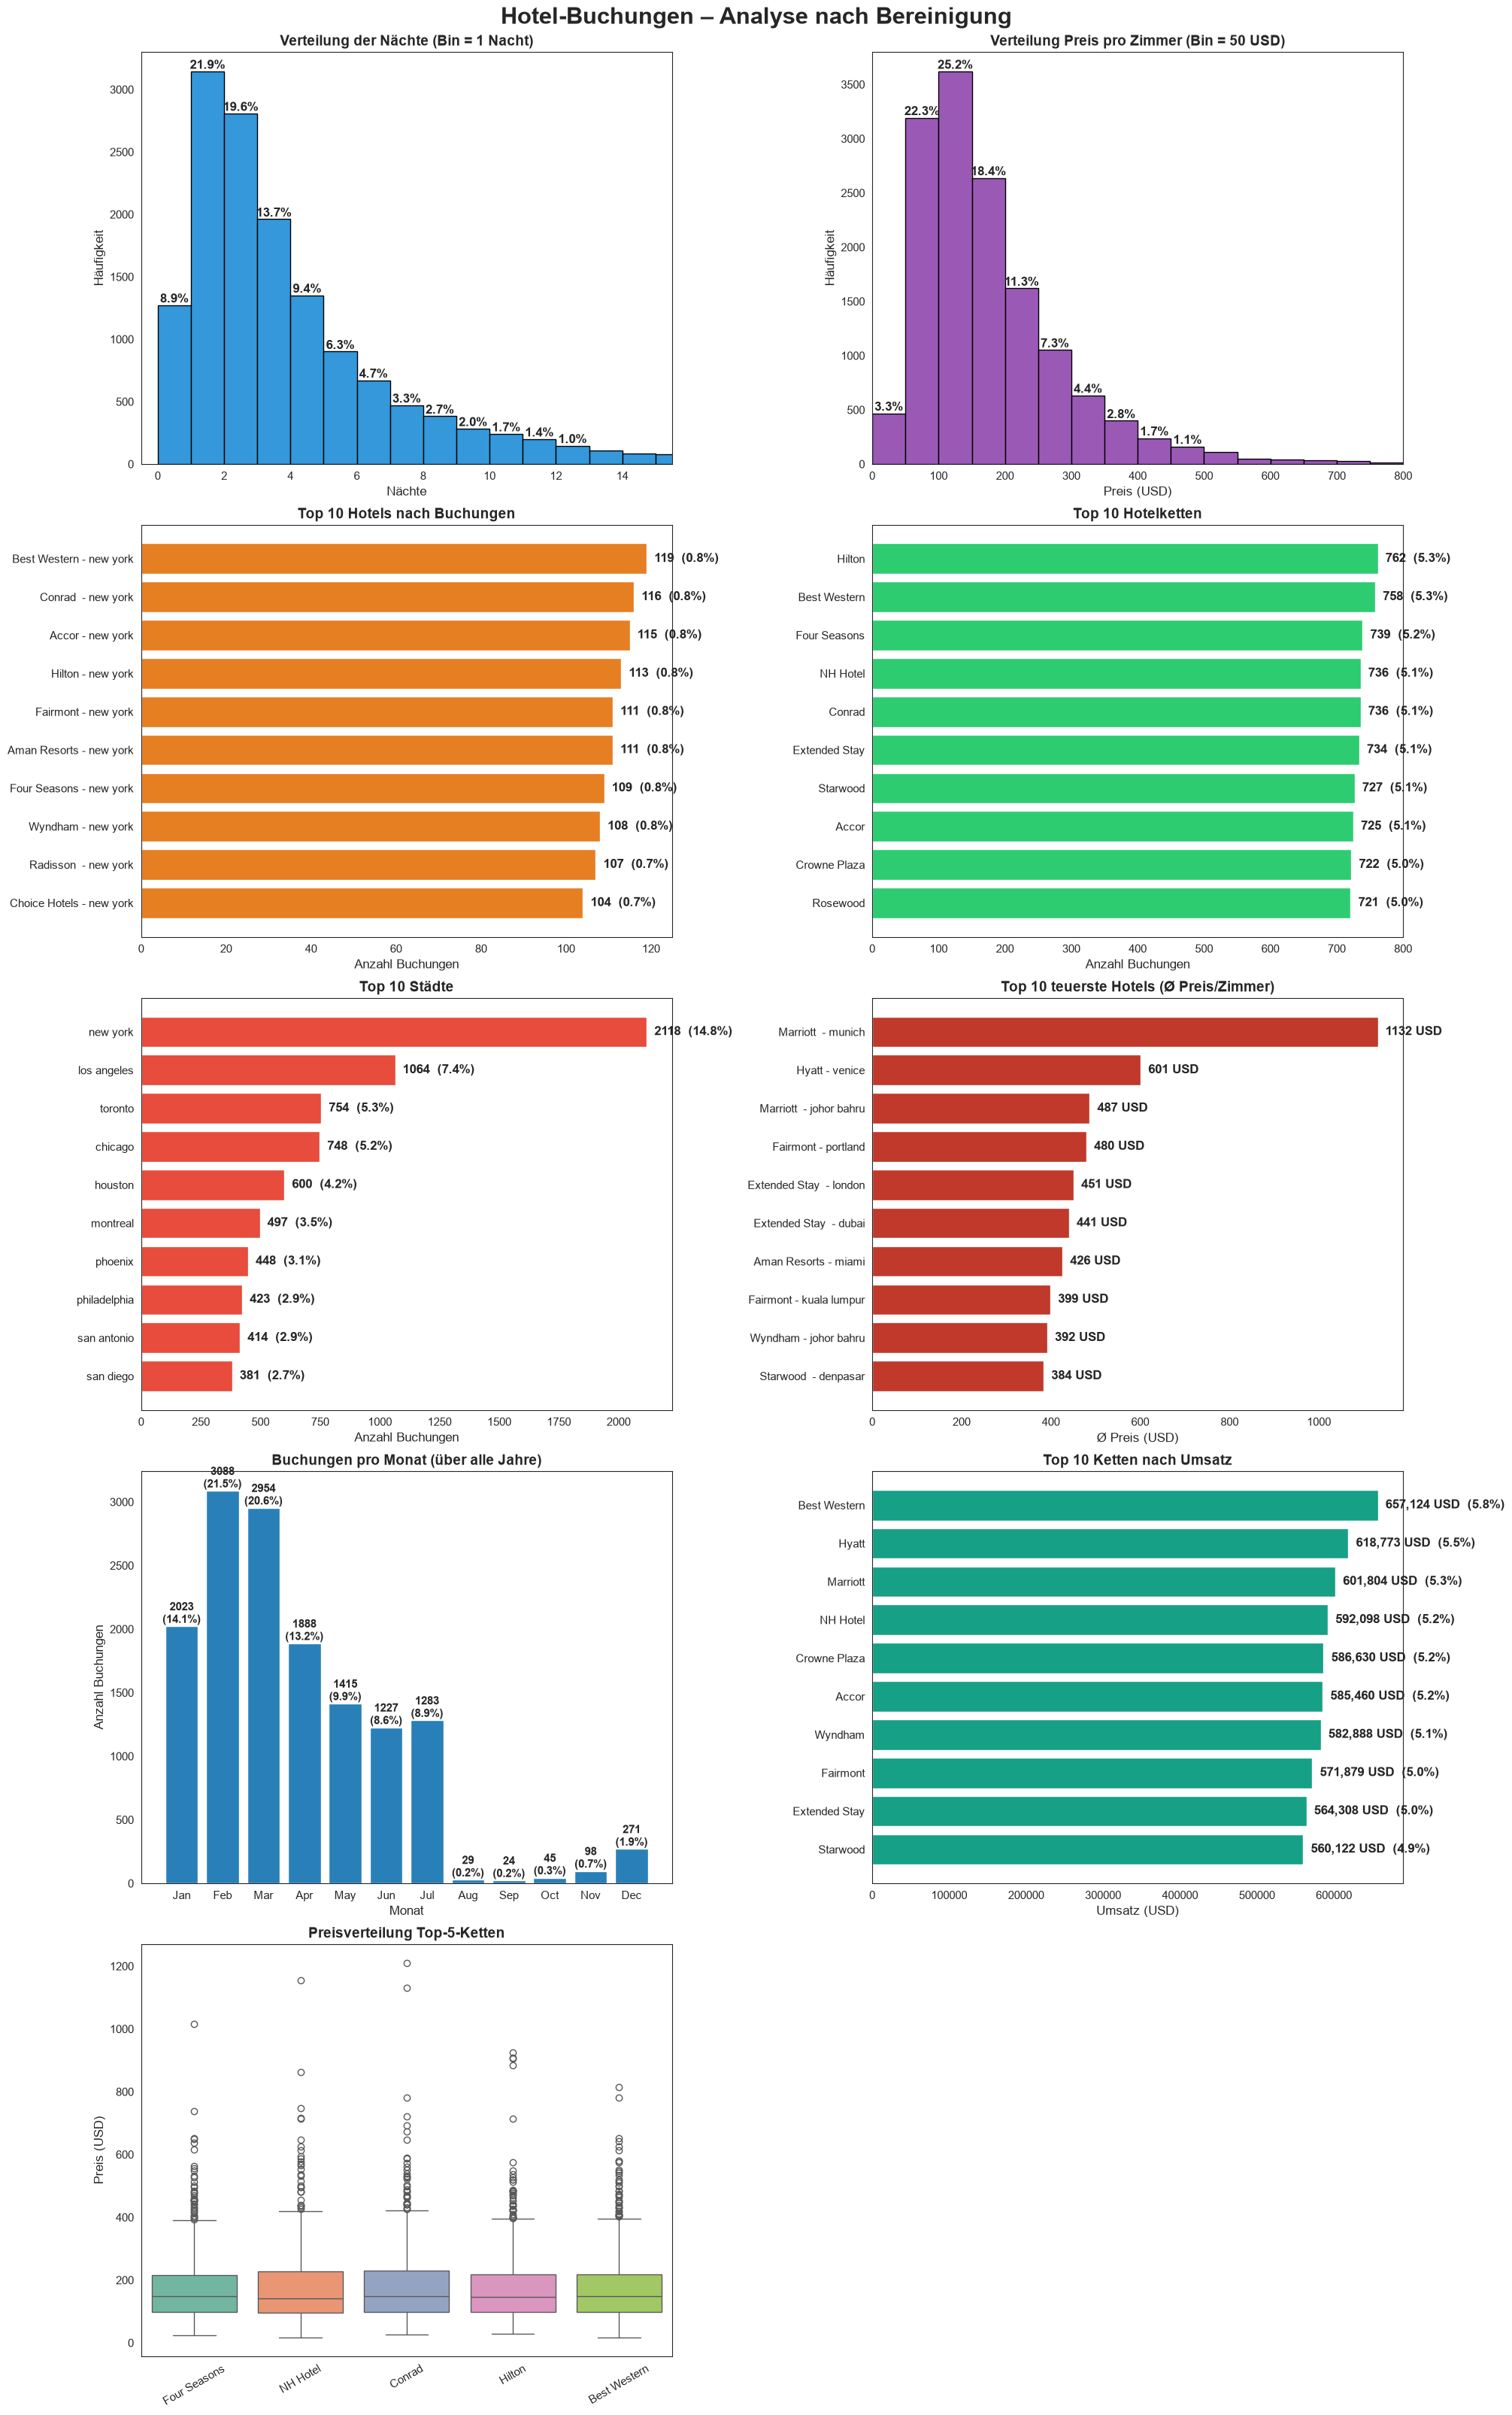

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==================================================================
# 1. BEREINIGTE DATEN LADEN
# ==================================================================
df = pd.read_csv("../data/preprocessed/hotels_cleaned.csv")
df["check_in_time"]  = pd.to_datetime(df["check_in_time"])
df["check_out_time"] = pd.to_datetime(df["check_out_time"])

# Kette und Stadt extrahieren
df["kette"] = df["hotel_name"].str.split(" - ").str[0].str.strip()
df["stadt"] = df["hotel_name"].str.split(" - ").str[1].str.strip()

# Umsatz pro Buchung
df["umsatz"] = df["nights"] * df["rooms"] * df["hotel_per_room_usd"]

# Monat OHNE Jahr – für Gruppierung über alle Jahre hinweg
df["check_in_monat_num"] = df["check_in_time"].dt.month

# Stil ohne Grid
sns.set_style("white")

# Globale Schriftgröße
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# ==================================================================
# 2. DASHBOARD – 2 SPALTEN (5 Zeilen) mit constrained_layout
# ==================================================================
fig, axes = plt.subplots(5, 2, figsize=(20, 32), constrained_layout=True)
fig.suptitle("Hotel-Buchungen – Analyse nach Bereinigung",
             fontsize=22, fontweight="bold")

axes = axes.flatten()
total = len(df)

# Leere 10. Zelle komplett entfernen
axes[9].remove()

# ==================================================================
# Plot 1: Verteilung der Nächte (Bin = 1 Nacht)
# ==================================================================
max_nights = int(df["nights"].max())
bins_naechte = np.arange(0, max_nights + 1, 1)

n, bins, patches = axes[0].hist(
    df["nights"],
    bins=bins_naechte,
    color="#3498db",
    edgecolor="black",
    density=False
)
axes[0].set_title("Verteilung der Nächte (Bin = 1 Nacht)", fontweight="bold")
axes[0].set_xlabel("Nächte")
axes[0].set_ylabel("Häufigkeit")
axes[0].set_xlim(-0.5, 15.5)
axes[0].grid(False)

for i in range(min(15, len(n))):
    if n[i] > 0:
        prozent = n[i] / total * 100
        if prozent >= 1:
            x_center = (bins[i] + bins[i+1]) / 2
            axes[0].text(x_center, n[i], f"{prozent:.1f}%",
                         ha="center", va="bottom",
                         fontsize=12, fontweight="bold")

# ==================================================================
# Plot 2: Verteilung Preis pro Zimmer (Bin = 50 USD)
# ==================================================================
max_preis = df["hotel_per_room_usd"].max()
bins_preis = np.arange(0, max_preis + 50, 50)

n2, bins2, patches2 = axes[1].hist(
    df["hotel_per_room_usd"],
    bins=bins_preis,
    color="#9b59b6",
    edgecolor="black",
    density=False
)
axes[1].set_title("Verteilung Preis pro Zimmer (Bin = 50 USD)", fontweight="bold")
axes[1].set_xlabel("Preis (USD)")
axes[1].set_ylabel("Häufigkeit")
axes[1].set_xlim(0, 800)
axes[1].grid(False)

for i in range(len(n2)):
    if n2[i] > 0 and bins2[i] <= 800:
        prozent = n2[i] / total * 100
        if prozent >= 1:
            x_center = (bins2[i] + bins2[i+1]) / 2
            axes[1].text(x_center, n2[i], f"{prozent:.1f}%",
                         ha="center", va="bottom",
                         fontsize=12, fontweight="bold")

# ==================================================================
# Plot 3: Top 10 Hotels nach Buchungen
# ==================================================================
top_hotels = df["hotel_name"].value_counts().head(10)
bars = axes[2].barh(top_hotels.index[::-1], top_hotels.values[::-1], color="#e67e22")
axes[2].set_title("Top 10 Hotels nach Buchungen", fontweight="bold")
axes[2].set_xlabel("Anzahl Buchungen")
axes[2].grid(False)
for b, v in zip(bars, top_hotels.values[::-1]):
    axes[2].text(v, b.get_y() + b.get_height()/2,
                 f"  {v}  ({v/total*100:.1f}%)",
                 va="center", fontsize=12, fontweight="bold")

# ==================================================================
# Plot 4: Top 10 Hotelketten
# ==================================================================
top_ketten = df["kette"].value_counts().head(10)
bars = axes[3].barh(top_ketten.index[::-1], top_ketten.values[::-1], color="#2ecc71")
axes[3].set_title("Top 10 Hotelketten", fontweight="bold")
axes[3].set_xlabel("Anzahl Buchungen")
axes[3].grid(False)
for b, v in zip(bars, top_ketten.values[::-1]):
    axes[3].text(v, b.get_y() + b.get_height()/2,
                 f"  {v}  ({v/total*100:.1f}%)",
                 va="center", fontsize=12, fontweight="bold")

# ==================================================================
# Plot 5: Top 10 Städte
# ==================================================================
top_staedte = df["stadt"].value_counts().head(10)
bars = axes[4].barh(top_staedte.index[::-1], top_staedte.values[::-1], color="#e74c3c")
axes[4].set_title("Top 10 Städte", fontweight="bold")
axes[4].set_xlabel("Anzahl Buchungen")
axes[4].grid(False)
for b, v in zip(bars, top_staedte.values[::-1]):
    axes[4].text(v, b.get_y() + b.get_height()/2,
                 f"  {v}  ({v/total*100:.1f}%)",
                 va="center", fontsize=12, fontweight="bold")

# ==================================================================
# Plot 6: Top 10 teuerste Hotels (Ø Preis)
# ==================================================================
top_teuer = (df.groupby("hotel_name")["hotel_per_room_usd"]
               .mean().sort_values(ascending=False).head(10))
bars = axes[5].barh(top_teuer.index[::-1], top_teuer.values[::-1], color="#c0392b")
axes[5].set_title("Top 10 teuerste Hotels (Ø Preis/Zimmer)", fontweight="bold")
axes[5].set_xlabel("Ø Preis (USD)")
axes[5].grid(False)
for b, v in zip(bars, top_teuer.values[::-1]):
    axes[5].text(v, b.get_y() + b.get_height()/2,
                 f"  {v:.0f} USD",
                 va="center", fontsize=12, fontweight="bold")

# ==================================================================
# Plot 7: Buchungen pro Monat – nur Monatsnamen, über alle Jahre
# ==================================================================
monat_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

monat_counts = (df.groupby("check_in_monat_num")
                  .size()
                  .reindex(range(1, 13), fill_value=0))

monat_labels = [monat_map[m] for m in monat_counts.index]

bars = axes[6].bar(range(len(monat_counts)), monat_counts.values, color="#2980b9")
axes[6].set_title("Buchungen pro Monat (über alle Jahre)", fontweight="bold")
axes[6].set_xlabel("Monat")
axes[6].set_ylabel("Anzahl Buchungen")
axes[6].set_xticks(range(len(monat_counts)))
axes[6].set_xticklabels(monat_labels)
axes[6].grid(False)
for b, v in zip(bars, monat_counts.values):
    if v > 0:
        prozent = v / total * 100
        axes[6].text(b.get_x() + b.get_width()/2, v,
                     f"{v}\n({prozent:.1f}%)",
                     ha="center", va="bottom",
                     fontsize=11, fontweight="bold")

# ==================================================================
# Plot 8: Top 10 Ketten nach Umsatz
# ==================================================================
umsatz_kette = (df.groupby("kette")["umsatz"].sum()
                  .sort_values(ascending=False).head(10))
gesamt_umsatz = df["umsatz"].sum()
bars = axes[7].barh(umsatz_kette.index[::-1], umsatz_kette.values[::-1], color="#16a085")
axes[7].set_title("Top 10 Ketten nach Umsatz", fontweight="bold")
axes[7].set_xlabel("Umsatz (USD)")
axes[7].grid(False)
for b, v in zip(bars, umsatz_kette.values[::-1]):
    axes[7].text(v, b.get_y() + b.get_height()/2,
                 f"  {v:,.0f} USD  ({v/gesamt_umsatz*100:.1f}%)",
                 va="center", fontsize=12, fontweight="bold")

# ==================================================================
# Plot 9: Preisverteilung Top-5-Ketten (Boxplot)
# ==================================================================
top5_ketten = df["kette"].value_counts().head(5).index
df_top5 = df[df["kette"].isin(top5_ketten)]

sns.boxplot(
    data=df_top5,
    x="kette",
    y="hotel_per_room_usd",
    hue="kette",
    legend=False,
    palette="Set2",
    ax=axes[8]
)
axes[8].set_title("Preisverteilung Top-5-Ketten", fontweight="bold")
axes[8].set_xlabel("")
axes[8].set_ylabel("Preis (USD)")
axes[8].tick_params(axis="x", rotation=30)
axes[8].grid(False)



# ==================================================================
# 3. SPEICHERN
# ==================================================================
os.makedirs("../report", exist_ok=True)
fig.savefig("../report/Hotels_Analysis_Dashboard.png", dpi=180, bbox_inches="tight")
print("Gespeichert: ../report/Hotels_Analysis_Dashboard.png")

plt.show()

Hier sind die **Kernaussagen** aus deinem Dashboard – strukturiert nach den wichtigsten Erkenntnissen:

## 📊 Kernaussagen – Hotel-Buchungsanalyse

### 1. Aufenthaltsdauer
- **Kurzaufenthalte dominieren**: Über **60 % aller Buchungen** sind **1–3 Nächte**.
- **1 Nacht** ist der häufigste Fall (~22 %), gefolgt von **2 Nächten** (~20 %) und **3 Nächten** (~14 %).
- Langzeitaufenthalte (≥ 10 Nächte) sind eine **Randerscheinung** (< 6 %).

### 2. Preisverteilung
- Der **Großteil der Zimmerpreise liegt zwischen 50 und 200 USD** (~66 % aller Buchungen).
- Der **häufigste Preisbereich ist 50–150 USD** – typisch für Business- und Mittelklasse-Hotels.
- **Luxuspreise > 500 USD** sind selten (< 5 %).

### 3. Beliebte Städte
- **New York ist mit Abstand die Top-Stadt** – **14,8 %** aller Buchungen (2.118 Buchungen).
- Danach: **Los Angeles (7,4 %)**, **Toronto (5,3 %)**, **Chicago (5,2 %)**.
- Die **Top-10-Städte machen ~45 % aller Buchungen** aus → starke geografische Konzentration auf Nordamerika.

### 4. Hotelketten
- Die **Top-10-Ketten sind nahezu gleichauf** (~720–760 Buchungen, je ~5 %).
- **Hilton, Best Western, Four Seasons** führen leicht.
- **Keine Kette dominiert** → der Markt ist fragmentiert, Vielfalt für Kunden.

### 5. Top-Hotels
- Die **Top-10-Hotels liegen alle in New York** – jeweils ~0,7–0,8 % aller Buchungen.
- Das bestätigt: **New York ist der wichtigste Markt** im Datensatz.
- Interessant: Die Top-Hotels gehören zu **verschiedenen Ketten** (Best Western, Conrad, Accor, Hilton, Fairmont, Aman, Four Seasons, Wyndham, Radisson, Choice).

### 6. Umsatz
- **Best Western führt nach Umsatz** mit **657.124 USD (5,8 %)**, dicht gefolgt von Hyatt, Marriott und NH Hotel.
- **Top-10-Ketten erwirtschaften ~52 % des Gesamtumsatzes** – also mehr als die Hälfte.
- Der **Umsatz ist ähnlich verteilt wie die Buchungszahlen** → kein Ausreißer nach oben oder unten.

### 7. Saisonale Muster
- **Extremer Peak im März** (3.088 Buchungen, **21,5 %**).
- **Starke Monate**: Januar (14,1 %), Februar (20,6 %), April (13,2 %).
- **Schwache Monate**: **September, Oktober, November, Dezember** (< 1 % zusammen).
- **Sommer (Juni–August)**: moderat (5–9 %).
- ➡️ **Q1 ist mit Abstand die stärkste Buchungszeit** – klassisch für Business-Travel und Winterurlaub.

### 8. Preise nach Ketten (Top 5)
- **Four Seasons und NH Hotel** zeigen **die höchsten Ausreißer** (bis ~1.200 USD).
- **Conrad, Hilton, Best Western** liegen preislich enger beieinander.
- **Median-Preise** liegen bei allen Top-5-Ketten zwischen **150 und 200 USD**.
- ➡️ **Luxusketten haben eine breitere Preisspanne**, Economy-Ketten sind konsistenter.

---

## 🎯 Zusammenfassung in einem Satz

> **Die Hotelbuchungen sind stark auf Nordamerika (v. a. New York) konzentriert, mit überwiegend kurzen Aufenthalten (1–3 Nächte), mittleren Preisen (50–200 USD) und einem klaren Saison-Peak im ersten Quartal – bei einem fragmentierten Markt ohne dominierende Kette.**

---

